<a href="https://colab.research.google.com/github/varshamqa/AutomateBrowserSerVSC-M1/blob/master/AI_ML_Varsha_Sonar_KNNAlgo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1: Importing required libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# **Step 2: Importing the Dataset**

In [2]:
df=pd.read_csv('/content/sonar.all-data.csv')

# **The sonar dataset**
Sonar (sound navigation ranging) is a technique that uses sound propagation (usually underwater, as in submarine navigation) to navigate, communicate with or detect objects on or under the surface of the water, such as other vessels. The data set contains the response metrics for 60 separate sonar frequencies sent out against a known mine field (and known rocks). These frequencies are then labeled with the known object they were beaming the sound at (either a rock or a mine). Our main goal is to create a machine learning model capable of detecting the difference between a rock or a mine based on the response of the 60 separate sonar frequencies.

Data Source:
https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks)

In [11]:
# Data overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Freq_1   208 non-null    float64
 1   Freq_2   208 non-null    float64
 2   Freq_3   208 non-null    float64
 3   Freq_4   208 non-null    float64
 4   Freq_5   208 non-null    float64
 5   Freq_6   208 non-null    float64
 6   Freq_7   208 non-null    float64
 7   Freq_8   208 non-null    float64
 8   Freq_9   208 non-null    float64
 9   Freq_10  208 non-null    float64
 10  Freq_11  208 non-null    float64
 11  Freq_12  208 non-null    float64
 12  Freq_13  208 non-null    float64
 13  Freq_14  208 non-null    float64
 14  Freq_15  208 non-null    float64
 15  Freq_16  208 non-null    float64
 16  Freq_17  208 non-null    float64
 17  Freq_18  208 non-null    float64
 18  Freq_19  208 non-null    float64
 19  Freq_20  208 non-null    float64
 20  Freq_21  208 non-null    float64
 21  Freq_22  208 non

As can be seen, there is no missing value.

 **Step 3: Exploratory Data Analysis**

In [4]:
df["Label"].value_counts()

,count
Label,
M,111
R,97


<Axes: xlabel='Label', ylabel='count'>

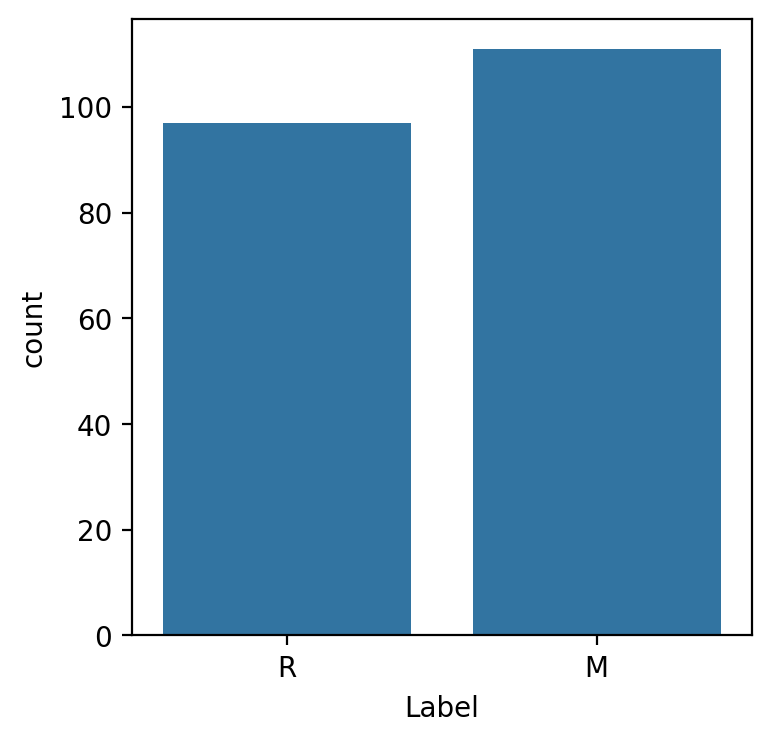

In [8]:
plt.figure(figsize=(4,4),  dpi=200)
sns.countplot(data=df,x="Label")

# **Step 4: Determining the Features and the Target Variable**


In [9]:
X= df.drop('Label', axis=1)
y= df['Label']

# **Step 5: Spliting the Data to Train & Test**

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# **Step 6: Feature Scaling**
It should be mentioned that feature scaling is compulsory in the KNN algorithm.

In [12]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
scaler.fit(X_train)
scaled_X_train= scaler.transform(X_train)
scaled_X_test= scaler.transform(X_test)

# **Step 7: Training the Model**
K nearset neighbors (KNN) assigns a label to new data according to the distance between the old data and the new data.
Pr(Y=j|X=x0)=1/K×∑i∈N0I(yi=j)

In [13]:
from sklearn.neighbors import KNeighborsClassifier
knn_model= KNeighborsClassifier(n_neighbors=1)
knn_model.fit(scaled_X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

# **Step 8: Prediction**

In [14]:
y_pred= knn_model.predict(scaled_X_test)

In [15]:
#A comparison between predicted Value vs Actual Values

pd.DataFrame({'Y_Test':y_test, 'Y_Pred': y_pred})

,Y_Test,Y_Pred
177,M,R
112,M,M
182,M,M
148,M,R
183,M,M
...,...,...
179,M,M
9,R,R
161,M,M
36,R,R


# **Step 9: Evaluating the Model**

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_score(y_test, y_pred)

0.873015873015873

In [17]:
confusion_matrix(y_test, y_pred)

array([[26,  4],
       [ 4, 29]])

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           M       0.87      0.87      0.87        30
           R       0.88      0.88      0.88        33

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63



# **Step 10: Selecting the best K**

# *1st*  Method: Elbow Method

In [19]:
test_error_rate= []


for k in range (1, 30):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_X_train, y_train)

    y_pred_test = knn_model.predict(scaled_X_test)

    test_error=1- accuracy_score(y_test, y_pred_test)
    test_error_rate.append(test_error)

In [20]:
test_error_rate

[0.12698412698412698,
 0.2222222222222222,
 0.2063492063492064,
 0.23809523809523814,
 0.2222222222222222,
 0.2063492063492064,
 0.23809523809523814,
 0.2857142857142857,
 0.23809523809523814,
 0.31746031746031744,
 0.3015873015873016,
 0.31746031746031744,
 0.3015873015873016,
 0.3492063492063492,
 0.2857142857142857,
 0.31746031746031744,
 0.31746031746031744,
 0.31746031746031744,
 0.31746031746031744,
 0.33333333333333337,
 0.3015873015873016,
 0.31746031746031744,
 0.2698412698412699,
 0.31746031746031744,
 0.3015873015873016,
 0.2857142857142857,
 0.2857142857142857,
 0.2857142857142857,
 0.25396825396825395]

Text(0.5, 0, 'K Value')

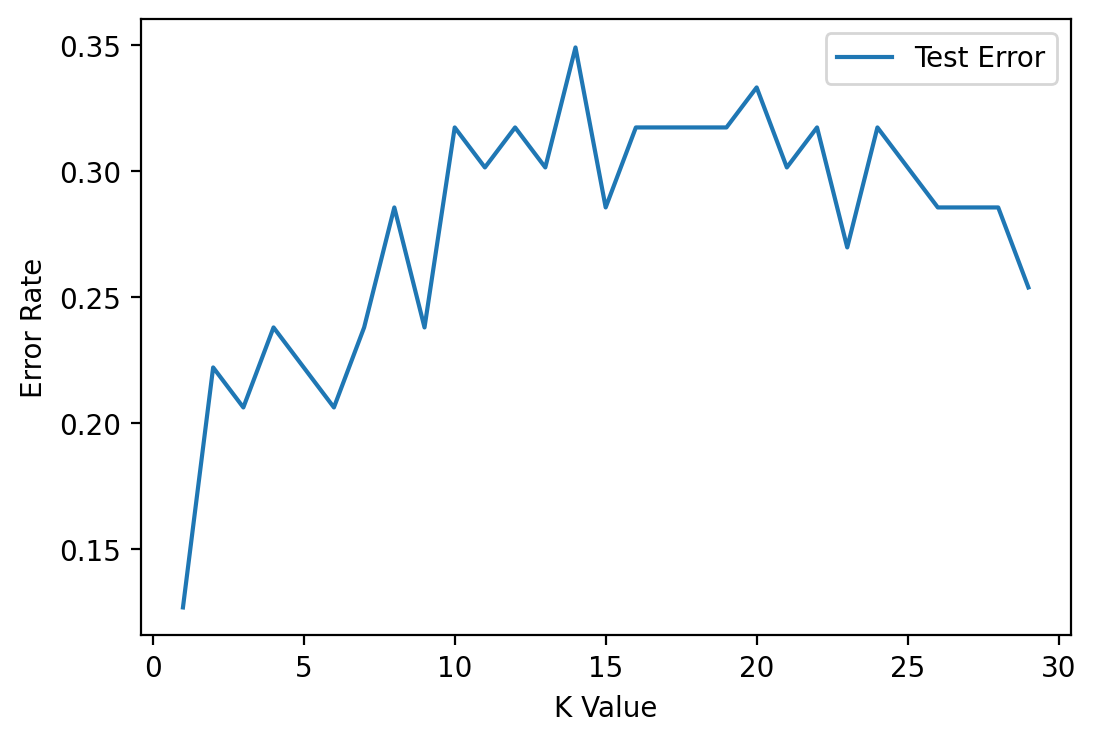

In [21]:
plt.figure(figsize=(6, 4), dpi = 200)
plt.plot(range(1, 30), test_error_rate, label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel('K Value')

# *2nd*  Method: Grid Search Cross Validation _ A Pipeline application



In [22]:
scaler= StandardScaler()
knn= KNeighborsClassifier()
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [23]:
operations= [('scaler', scaler), ('knn', knn)]
from sklearn.pipeline import Pipeline
pipe= Pipeline(operations)
from sklearn.model_selection import GridSearchCV
k_values= list(range(1, 20))
param_grid= {'knn__n_neighbors': k_values}
full_cv_classifier= GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
full_cv_classifier.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19]},
             scoring='accuracy')

In [24]:
full_cv_classifier.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier(n_neighbors=1))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(n_neighbors=1),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 1,
 'knn__p': 2,
 'knn__weights': 'uniform'}

As shown, it is more desirable to set K equal to 1.


In [25]:
full_cv_classifier.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_knn__n_neighbors', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

# **Step 11: Finilizing the model**

In [26]:
scaler= StandardScaler()
knn1= KNeighborsClassifier(n_neighbors=1)
operations= [('scaler', scaler), ('knn1', knn1)]

In [27]:
pipe= Pipeline(operations)
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn1', KNeighborsClassifier(n_neighbors=1))])

In [28]:
pipe_pred= pipe.predict(X_test)

In [29]:
print(classification_report(y_test, pipe_pred))

              precision    recall  f1-score   support

           M       0.87      0.87      0.87        30
           R       0.88      0.88      0.88        33

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63

